# In this version, I give up to make the axes compatible with that of XPP. I'll try to achieve that in the next version

## Definition
1. um, fs, keV
2. normal is pointing inwards the reflection surface
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (code x, code y, code z) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z)
    i.e., The name in this code is x,y,z, using one convension. In the text, use the XPP convention 
   
## Convention for FFT

np.fft(field) = spectrum

np.ifft(spectrum) = field

## Description of the model.
In this model, we align the two mirrors for the TG with the CC branch after miniSD.
In this way, we reduce the degree of freedom to make both the simulation and the 
actual operation of this setup easier.

The open question is that if we can get enough delay time in this configuration. 

# Step 1: Ray Tracing Calculation

In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("../../../../XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal
from rayTracingCalculation import prepare_beam_optics, get_miniSD_and_TG_trajectory, \
    get_coefficient_for_two_configurations, get_trajectory_dependence_on_various_parameters

import physicalModelVisualization, eFieldProcessing

plt.rcParams.update({'font.size': 14})

In [2]:
expSimu = get_miniSD_and_TG_trajectory()
(t2x_coef, t3x_coef, t4x_coef, t5x_coef,
 probe1z_coef, probe1alpha_coef, probe2z_coef,
 pump1z_coef, pump1alpha_coef, pump2z_coef, pump2alpha_coef) = get_trajectory_dependence_on_various_parameters()

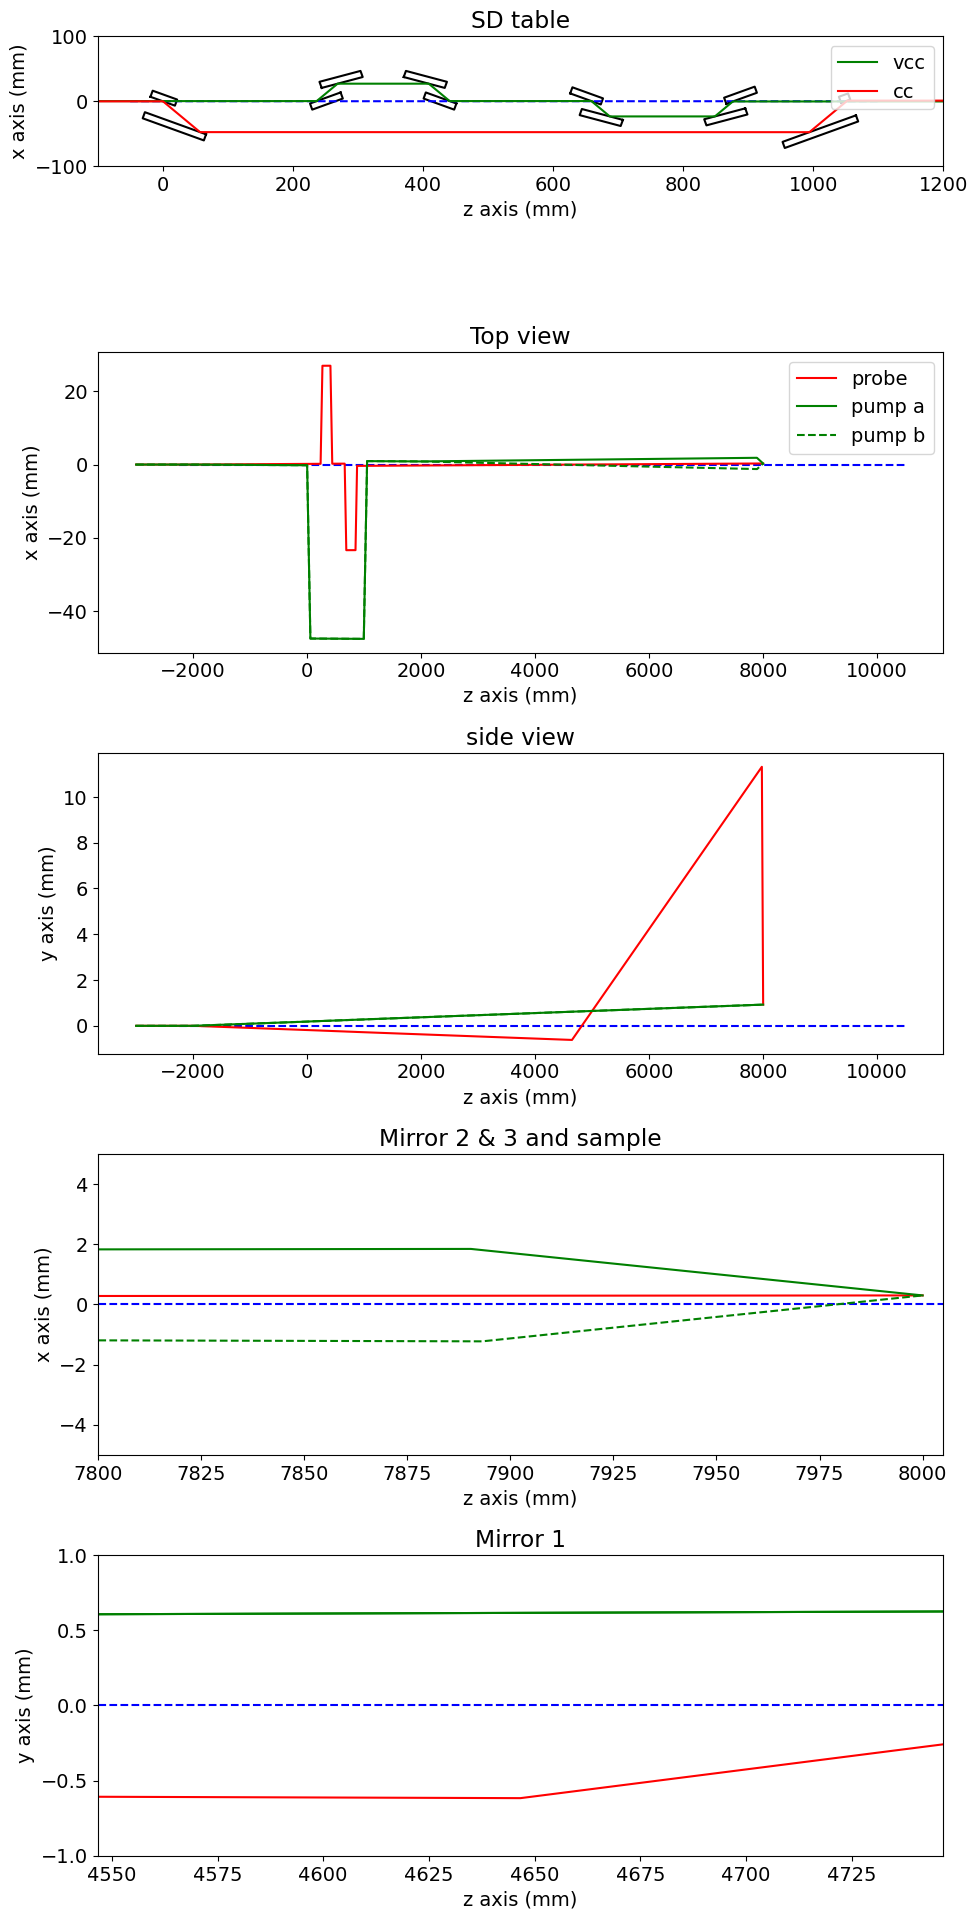

In [3]:
physicalModelVisualization.showSDandTGtrajectory(simulation_summary=expSimu)

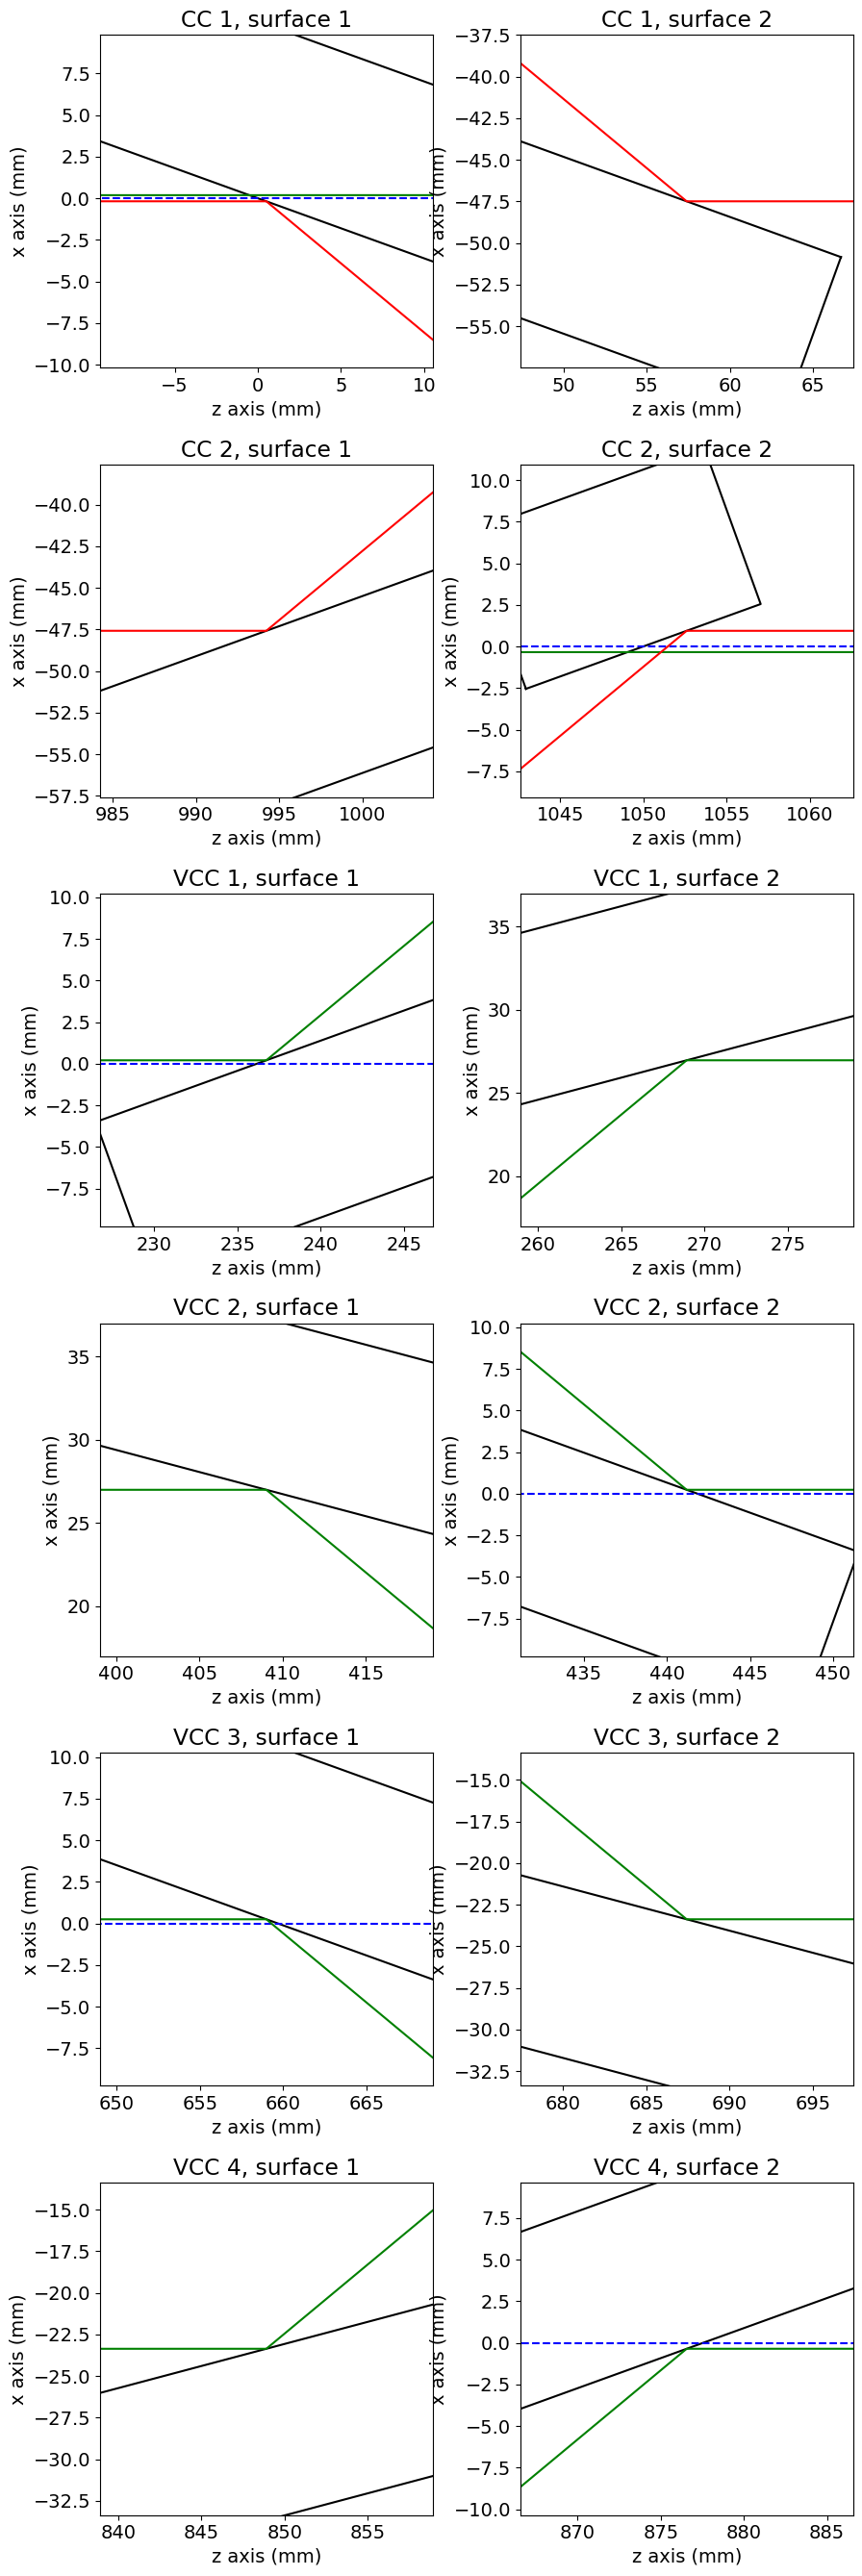

In [4]:
physicalModelVisualization.showCrystalEdges(simulation_summary=expSimu)

In [5]:
# Calculate the modification needed to impose to these optics
# -------------------------------------------------------
#     Overlap the TG pulse pair along the x axis
# -------------------------------------------------------
# Get current horizontal separation
pump_0 = expSimu['TG pump 0']['trajectory'][-1]
pump_a = expSimu['TG pump a']['trajectory'][-1]
pump_b = expSimu['TG pump b']['trajectory'][-1]

move_a = (pump_0[1] - pump_a[1]) / pump1z_coef['pump a']['position'][1]
move_b = (pump_0[1] - pump_b[1]) / pump2z_coef['pump b']['position'][1]

print("To make the two TG pulse overlap with the 0th order")
print("mirror-a move {:.2f}".format(move_a))
print("mirror-b move {:.2f}".format(move_b))

# -------------------------------------------------------
#     Overlap the probe pulse along the vertical position
# -------------------------------------------------------
probe = expSimu['TG probe']['trajectory'][-1]

move_si = (pump_0[0] - probe[0]) / probe2z_coef['probe']['position'][0]

print("To make the probe pulse overlap vertically with the pump pulse")
print("Move silicon 111 by {:.2f}".format(move_si))

# -------------------------------------------------------
#     Overlap the probe pulse along the horizontal position
# -------------------------------------------------------
move_t4_t5 = (pump_a[1] - probe[1]) / t4x_coef['probe']['position'][1] / 2
print("To make the probe pulse overlap horizontally with the pump pulse")
print("Move t4x positive and t5x negative by {:.2f}".format(move_t4_t5))

# -------------------------------------------------------
#     Calculate the path length difference
# -------------------------------------------------------
pathdiff_probe_a = (expSimu['TG probe']['pathLength'] - expSimu['TG pump a']['pathLength']) / util.c / 1000
print("Probe arrives {:.2f} ps later than pump a".format(pathdiff_probe_a))

pathdiff_probe_b = (expSimu['TG probe']['pathLength'] - expSimu['TG pump b']['pathLength']) / util.c / 1000
print("Probe arrives {:.2f} ps later than pump b".format(pathdiff_probe_b))

# -----------------------------------------------------
#     Calculate the spatial separation at the first crystal
# -----------------------------------------------------
# Get the spatial separation of the two pulses at the first edge of CC1
pulse1_loc = expSimu['vcc']['kout'][1] / np.linalg.norm(expSimu['vcc']['kout'][1]) * 2e6
pulse2_loc = expSimu['cc']['kout'][1] / np.linalg.norm(expSimu['cc']['kout'][1]) * 2e6
print("Spatial separation at the first edge of CC1")
print(pulse2_loc - pulse1_loc)

# --------------------------------------------------------
#     Calculate the spatial separation at the TG total reflection mirror
# --------------------------------------------------------'
separation = expSimu['TG pump a']['trajectory'][-1] - expSimu['TG pump a']['trajectory'][-2]
print('separation in mm', separation / 1e3)

To make the two TG pulse overlap with the 0th order
mirror-a move 0.39
mirror-b move 0.00
To make the probe pulse overlap vertically with the pump pulse
Move silicon 111 by 0.88
To make the probe pulse overlap horizontally with the pump pulse
Move t4x positive and t5x negative by 0.06
Probe arrives 12.79 ps later than pump a
Probe arrives 12.79 ps later than pump b
Spatial separation at the first edge of CC1
[ 369.13711994 -369.13711994    0.        ]
separation in mm [ 1.01071518e-02 -1.54764321e+00  1.09510988e+02]


In [6]:
print(probe)
print(pump_a)
print(pump_b)

[9.25637676e+02 2.99691643e+02 8.00000000e+06]
[9.26039818e+02 2.99768303e+02 8.00000000e+06]
[9.26039818e+02 2.99773693e+02 8.00000000e+06]


# Step 2: Generate a SASE electric field

In [7]:
# Get all the devices
(my_pulse,
 miniSD_gratings_cc,
 miniSD_gratings_vcc,
 vcc_channel_cuts,
 cc_channel_cuts,
 TG_grating_a,
 TG_grating_b,
 TG_mirror_pump_a,
 TG_mirror_pump_b,
 TG_mirror_probe_list) = prepare_beam_optics()

# Specify the number of pixels and spatial resolutions for the simulation

nx = 4  # For y axis in XPP frame
ny = 128  # For x axis in XPP frame
nz = 1024  # For z axis in XPP frame

dx = 4
dy = 1
dz = 50 * util.c / nz  # The total pulse duration is 50 fs in this simulation

# Get kin grid
(xCoor, yCoor, zCoor, tCoor,
 kxCoor, kyCoor, kzCoor,
 ExCoor, EyCoor, EzCoor) = util.get_coordinate(nx=nx, ny=ny, nz=nz,
                                               dx=dx, dy=dy, dz=dz,
                                               k0=my_pulse.klen0)
coordinate_dict = {'xCoor': xCoor, 'yCoor': yCoor, 'zCoor': zCoor, 'tCoor': tCoor,
                   'kxCoor': kxCoor, 'kyCoor': kyCoor, 'kzCoor': kzCoor,
                   'ExCoor': ExCoor, 'EyCoor': EyCoor, 'EzCoor': EzCoor, }

kinGrid = np.zeros((nx, ny, nz, 3))
kinGrid[:, :, :, 0] = kxCoor[:, np.newaxis, np.newaxis]
kinGrid[:, :, :, 1] = kyCoor[np.newaxis, :, np.newaxis]
kinGrid[:, :, :, 2] = kzCoor[np.newaxis, np.newaxis, :]

# Get a more realistic electric field based on the ideal simple Gaussian pulse
# Get a total simulation duation of 100 fs
sase_field = Pulse.getGaussianModeSum(nx=nx, ny=ny, nz=nz, dx=dx, dy=dy, dz=dz,
                                      nGaussian=20,
                                      modeSizeX=5,
                                      modeSizeY=5,
                                      modeSizeZ=0.1,  # each mode is 3 fs
                                      modeCenterSpreadX=0.1,
                                      modeCenterSpreadY=0.1,
                                      modeCenterSpreadZ=4.5,  # The mode length is rough 15 fs or 4.5 um
                                      k0=my_pulse.klen0,
                                      randomSeed=41)

# Try to get the electric field after gpu calculation
sase_spec = np.fft.fftshift(np.fft.fftn(np.fft.fftshift(sase_field)))

# Collect the statistics of these fields
simulation_statistics = {}
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(sase_field)),
                                tag="sase intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(sase_spec)),
                                tag="sase spectrum")

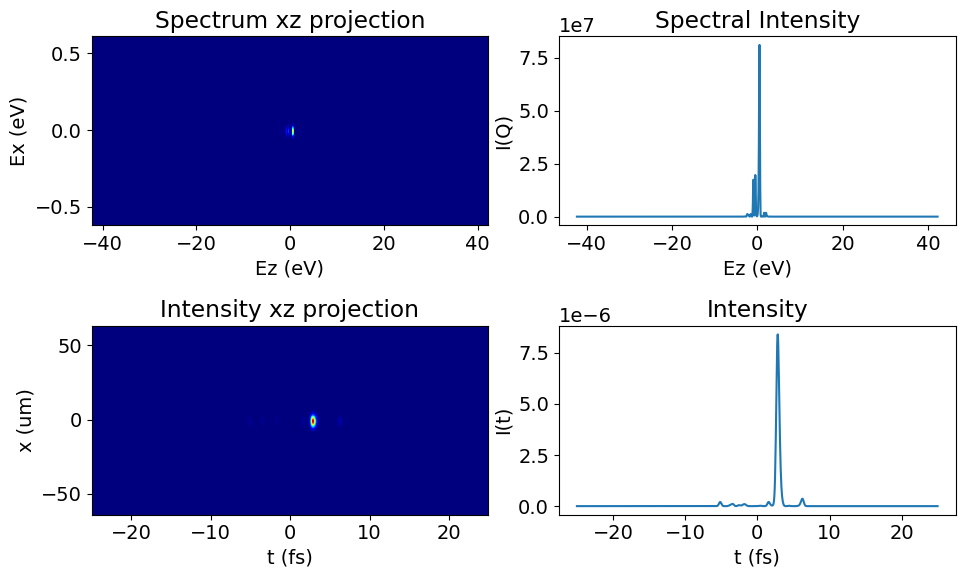

In [8]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["sase spectrum",
                                                                        'sase intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 3: Calculate the electric field after each crystal

In [9]:
print("The locations to investigate the electric field are")
print(expSimu['vcc']['trajectory'])

The locations to investigate the electric field are
[[ 0.00000000e+00  0.00000000e+00 -3.00000000e+06]
 [ 0.00000000e+00  0.00000000e+00 -2.00000000e+06]
 [-2.06415844e+02  2.06415844e+02  2.36738934e+05]
 [-2.10279106e+02  2.69707019e+04  2.68928251e+05]
 [-2.23206586e+02  2.69825201e+04  4.09011479e+05]
 [-2.27068463e+02  2.33258716e+02  4.41193771e+05]
 [-2.47168126e+02  2.49909185e+02  6.58995365e+05]
 [-2.50578771e+02 -2.33738949e+04  6.87417389e+05]
 [-2.65480676e+02 -2.33602714e+04  8.48895653e+05]
 [-2.68800930e+02 -3.57888468e+02  8.76560543e+05]
 [-4.64761014e+02 -1.61932167e+02  3.00000000e+06]
 [-4.64761014e+02 -1.61941072e+02  8.00000000e+06]]


## CC1

In [10]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 6e4])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_cc[0], ]
for idx in range(1):
    device_list += cc_channel_cuts[idx].crystal_list

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=False,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="cc1 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="cc1 spectrum")

The ray-tracing calculation differ from the actual beam center by a few pixels: [  2 112 129]


/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/numba/cuda/cudadrv/devicearray.py:886: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


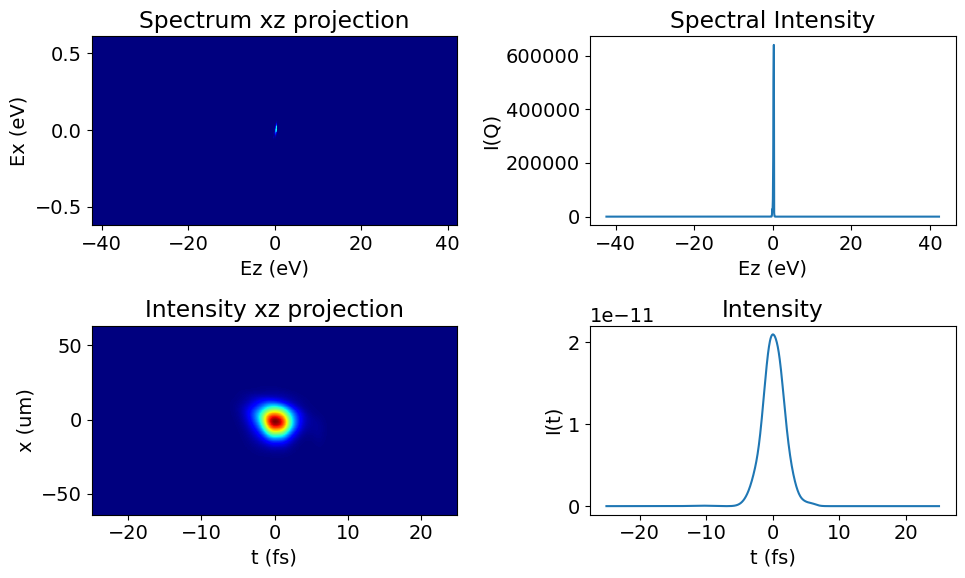

In [11]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["cc1 spectrum",
                                                                        'cc1 intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 2 Get the electric field after the second channelcut crystal

In [12]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 1.1e6])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_cc[0], ]
for idx in range(2):
    device_list += cc_channel_cuts[idx].crystal_list

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=False,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="cc2 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="cc2 spectrum")

The ray-tracing calculation differ from the actual beam center by a few pixels: [  2  10 329]


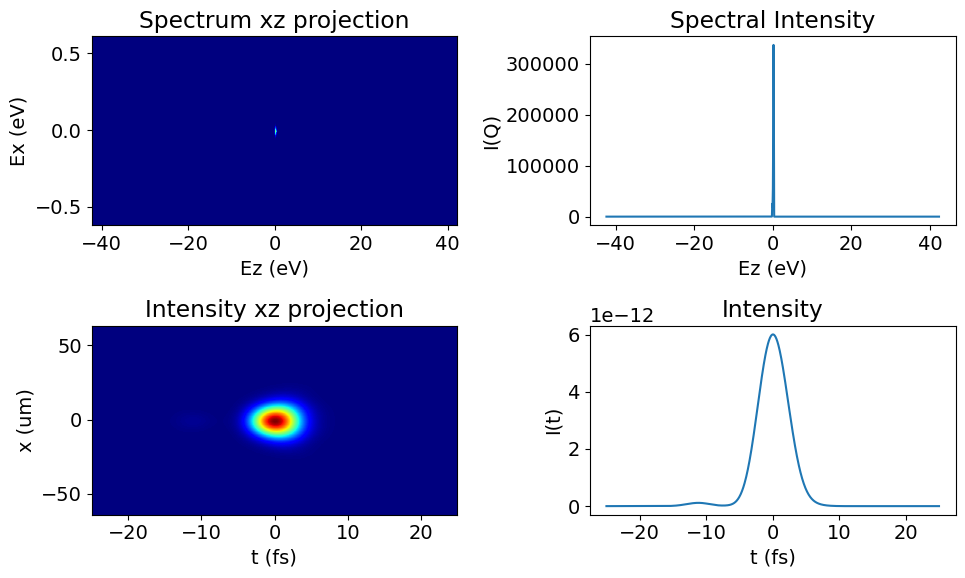

In [13]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["cc2 spectrum",
                                                                        'cc2 intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 3 Get the electric field after the second grating
Not to work on this at this moment.
I need to add focusing optics. 
Otherwise, it does not make sense to calculate this at all

# Step 4 Get the electric field on the sample plane

In [14]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 10e6])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_cc[0], ]
for idx in range(2):
    device_list += cc_channel_cuts[idx].crystal_list
device_list += [miniSD_gratings_cc[1], ]

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=False,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="cc sample intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="cc sample spectrum")

The ray-tracing calculation differ from the actual beam center by a few pixels: [  0  17 424]


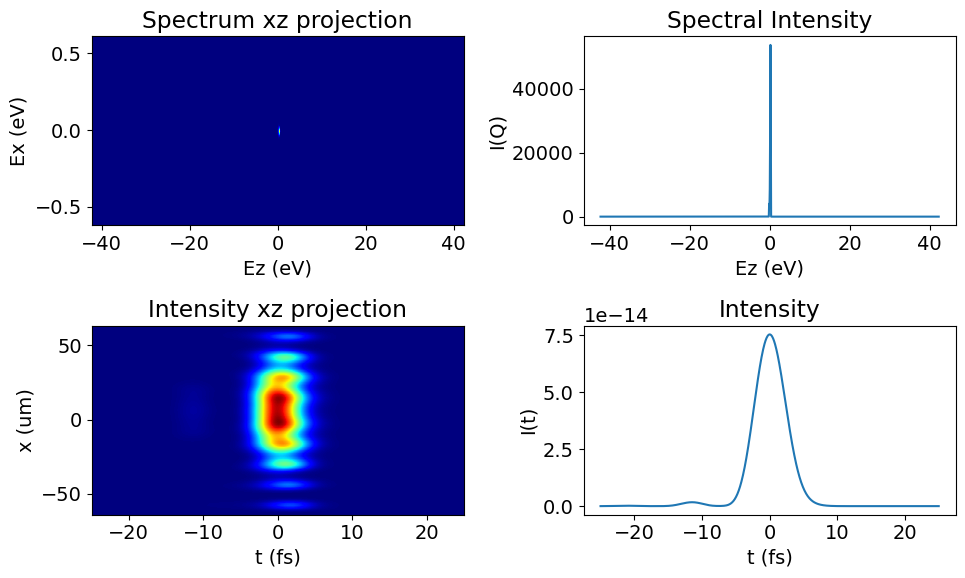

In [15]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["cc sample spectrum",
                                                                        'cc sample intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 5: Get the electric field after the first VCC

In [16]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 3e5])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_vcc[0], ]
for idx in range(1):
    device_list += vcc_channel_cuts[idx].crystal_list

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=True,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="vcc1 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="vcc1 spectrum")

The ray-tracing calculation differ from the actual beam center by a few pixels: [ 2 18 57]
Interpolate the electric field such that after the intpolation
the three axes of the array are parallel to that of the x,y,z axes.
[[ 6.25000000e-02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.28031349e-02 -3.59178872e-07]
 [ 0.00000000e+00 -1.54055512e-02  6.67141187e-02]]
[[ 1.60000000e+01  0.00000000e+00  0.00000000e+00]
 [-0.00000000e+00  7.81063766e+01  4.20513090e-04]
 [ 0.00000000e+00  1.80362389e+01  1.49894280e+01]]
[3.92699082e-01 5.45785639e-13 0.00000000e+00]
[ 0.00000000e+00  8.04444693e-02 -2.25678741e-06]
[ 0.         -0.09679593  0.41917717]
47 9919 171814


TypeError: cannot unpack non-iterable int object

In [ ]:
171814 / 2 ** 18

In [ ]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["vcc1 spectrum",
                                                                        'vcc1 intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 6: Get the electric field after the second VCC

In [ ]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 5e5])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_vcc[0], ]
for idx in range(2):
    device_list += vcc_channel_cuts[idx].crystal_list

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=True,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="vcc2 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="vcc2 spectrum")

In [ ]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["vcc2 spectrum",
                                                                        'vcc2 intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 7: Get the electric field after the thrid VCC

In [ ]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 7e5])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_vcc[0], ]
for idx in range(3):
    device_list += vcc_channel_cuts[idx].crystal_list

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=True,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="vcc3 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="vcc3 spectrum")

In [ ]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["vcc3 spectrum",
                                                                        'vcc3 intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 8: Get the electric field after the 4th VCC

In [ ]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 9e5])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_vcc[0], ]
for idx in range(4):
    device_list += vcc_channel_cuts[idx].crystal_list

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=True,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="vcc4 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="vcc4 spectrum")

In [ ]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["vcc4 spectrum",
                                                                        'vcc4 intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 9: Get the electric field from VCC branch on the sample

In [ ]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 10e6])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_vcc[0], ]
for idx in range(4):
    device_list += vcc_channel_cuts[idx].crystal_list
device_list += [miniSD_gratings_vcc[1], ]

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=True,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="vcc sample intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="vcc sample spectrum")

In [ ]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["vcc sample spectrum",
                                                                        'vcc sample intensity'],
                                                              coordinate_container=coordinate_dict)